# Metric Sensitivity Check: Semantic, Lexical and Syntactic Diversity

Robustness analysis for the three group-level diversity metrics

For a group (same prompt and source), all variants are aggregated in the same way:

\[
D(G)=\frac{1}{\binom{n}{2}}\sum_{i<j}d(t_i,t_j).
\]

Outputs are saved under:

- `figures/sem_lex_syn_diversity/`
- `metrics/05_sem_lex_syn_diversity/tables/`

In [1]:
# !pip install -U sentence-transformers spacy
# !python -m spacy download en_core_web_sm

In [2]:
# Load libraries
import hashlib
import json
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sentence_transformers import SentenceTransformer
import spacy
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)

/Users/thwin/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Print-oriented plotting defaults, close to the baseline notebook
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Configuration

In [4]:
DOMAINS = ['storytelling_n200', 'translation_ref3']  # subset of DOMAIN_CONFIG keys
SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
N_PROMPTS = 200


In [5]:
# Semantic encoders: MiniLM for baseline, Nomic Embed Text v1.5 for primary analysis
MINILM_MODEL = 'all-MiniLM-L6-v2'
NOMIC_MODEL = 'nomic-ai/nomic-embed-text-v1.5'
NOMIC_PREFIX = 'clustering: '   # symmetric task prefix, prepended to the raw text
NOMIC_MAX_LENGTH = 2048         # capped for memory safety (see NOMIC_DEVICE comment)

MINILM_BATCH_SIZE = 64
NOMIC_BATCH_SIZE = 4
SPACY_BATCH_SIZE = 64

# None = resolve current model revision
NOMIC_REVISION = None
MINILM_REVISION = None

# Device priority: CUDA > MPS > CPU
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

# Nomic is forced to CPU regardless of DEVICE
NOMIC_DEVICE = 'cpu'

print('Configuration:')
print(f'  Domains:   {DOMAINS}')
print(f'  Sources:   {SOURCES}')
print(f'  Device:    {DEVICE} (MiniLM)')
print(f'  Nomic dev: {NOMIC_DEVICE} (forced CPU, see comment above)')
print(f'  MiniLM:    {MINILM_MODEL}')
print(f'  Nomic:     {NOMIC_MODEL} (prefix={NOMIC_PREFIX!r}, capped max_length={NOMIC_MAX_LENGTH})')

Configuration:
  Domains:   ['storytelling_n200', 'translation_ref3']
  Sources:   ['human', 'llama', 'mistral', 'qwen', 'gemma']
  Device:    mps (MiniLM)
  Nomic dev: cpu (forced CPU, see comment above)
  MiniLM:    all-MiniLM-L6-v2
  Nomic:     nomic-ai/nomic-embed-text-v1.5 (prefix='clustering: ', capped max_length=2048)


# Load Dataset

In [6]:
# Repo root, robust to where the notebook itself is stored
def find_repo_root(start=None):
    start = Path(start or Path.cwd())
    for p in [start, *start.parents]:
        if (p / 'metrics' / 'metrics_lib').is_dir() and (p / 'data_generation' / 'generations').is_dir():
            return p
    raise FileNotFoundError(
        "Could not locate repo root (expected 'metrics/metrics_lib/' and "
        "'data_generation/generations/')."
    )


REPO_ROOT = find_repo_root()

FIG_DIR = REPO_ROOT / 'figures' / 'sem_lex_syn_diversity'
TABLE_DIR = REPO_ROOT / 'metrics' / '05_sem_lex_syn_diversity' / 'tables'
CACHE_DIR = REPO_ROOT / 'metrics' / '05_sem_lex_syn_diversity' / 'cache'

for p in (FIG_DIR, TABLE_DIR, CACHE_DIR):
    p.mkdir(parents=True, exist_ok=True)

print(f'Repo root: {REPO_ROOT}')
print(f'Figures:   {FIG_DIR}')
print(f'Tables:    {TABLE_DIR}')
print(f'Cache:     {CACHE_DIR}')

Repo root: /Users/thwin/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity
Figures:   /Users/thwin/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/sem_lex_syn_diversity
Tables:    /Users/thwin/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/metrics/05_sem_lex_syn_diversity/tables
Cache:     /Users/thwin/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/metrics/05_sem_lex_syn_diversity/cache


In [7]:
import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from common import data_prep
from common import MODEL_LABELS, MODEL_COLORS

# Canonical multi-domain load: quality filter (model: truncation / language drift; human:
# language drift + exact-duplicate) + storytelling human 5-cap
df = data_prep.load_many(DOMAINS, n_prompts=N_PROMPTS)

for _d in DOMAINS:
    _sub = df[df.domain == _d]
    print(f'[{_d}] loaded {len(_sub):,} texts')
    print(_sub.groupby('source').size().to_string())

print('\nCombined:')
print(df.groupby(['domain', 'source']).size())
df.head(3)

[storytelling_n200] loaded 4,972 texts
source
gemma      1000
human       999
llama       996
mistral     985
qwen        992
[translation_ref3] loaded 4,403 texts
source
gemma      936
human      669
llama      991
mistral    973
qwen       834

Combined:
domain             source 
storytelling_n200  gemma      1000
                   human       999
                   llama       996
                   mistral     985
                   qwen        992
translation_ref3   gemma       936
                   human       669
                   llama       991
                   mistral     973
                   qwen        834
dtype: int64


,domain,prompt_id,raw_prompt_id,source,story_id,prompt,text,model
0,storytelling_n200,0,wp_0000,human,0,Turns out that the purpose of life is war. Hum...,"Here is my first post, I have always wanted to...",Human
1,storytelling_n200,0,wp_0000,human,1,Turns out that the purpose of life is war. Hum...,`` The purpose of life is war. It has always b...,Human
2,storytelling_n200,0,wp_0000,human,2,Turns out that the purpose of life is war. Hum...,"“ Dr. Garyson, you have five seconds to cut to...",Human


In [8]:
# Sanity check: group sizes. All diversity metrics require >= 2 outputs per (domain, prompt, source).
group_sizes = (
    df.groupby(['domain', 'prompt_id', 'source'])
      .size()
      .rename('n_texts')
      .reset_index()
)

display(group_sizes.groupby(['domain', 'source'])['n_texts'].describe()[['min', 'mean', 'max']])

# Drop groups with fewer than 2 texts, if any
too_small = group_sizes[group_sizes['n_texts'] < 2]
if not too_small.empty:
    print(f'Dropping {len(too_small)} group(s) with fewer than 2 texts:')
    display(too_small)

    drop_keys = set(map(tuple, too_small[['domain', 'prompt_id', 'source']].to_numpy()))
    keep_mask = ~df[['domain', 'prompt_id', 'source']].apply(tuple, axis=1).isin(drop_keys)
    n_rows_dropped = (~keep_mask).sum()
    df = df[keep_mask].reset_index(drop=True)
    print(f'Dropped {n_rows_dropped} row(s); {len(df):,} rows remain.')

    group_sizes = (
        df.groupby(['domain', 'prompt_id', 'source'])
          .size()
          .rename('n_texts')
          .reset_index()
    )

too_small = group_sizes[group_sizes['n_texts'] < 2]
assert too_small.empty, f'Found groups with fewer than 2 texts:\n{too_small}'

min      mean  max
domain            source                     
storytelling_n200 gemma    5.0  5.000000  5.0
                  human    4.0  4.995000  5.0
                  llama    2.0  4.980000  5.0
                  mistral  4.0  4.925000  5.0
                  qwen     4.0  4.960000  5.0
translation_ref3  gemma    1.0  4.703518  5.0
                  human    3.0  3.345000  5.0
                  llama    3.0  4.955000  5.0
                  mistral  2.0  4.865000  5.0
                  qwen     1.0  4.366492  5.0

Dropping 13 group(s) with fewer than 2 texts:


,domain,prompt_id,source,n_texts
1029,translation_ref3,5,qwen,1
1099,translation_ref3,19,qwen,1
1234,translation_ref3,46,qwen,1
1493,translation_ref3,99,gemma,1
1507,translation_ref3,101,qwen,1
1625,translation_ref3,125,qwen,1
1670,translation_ref3,134,qwen,1
1759,translation_ref3,152,qwen,1
1764,translation_ref3,153,qwen,1
1789,translation_ref3,158,qwen,1


Dropped 13 row(s); 9,362 rows remain.


In [9]:
# Fingerprint the exact loaded text rows so stale caches cannot be silently reused
DATA_FINGERPRINT = data_prep.dataframe_fingerprint(df)
print(f'Dataset fingerprint: {DATA_FINGERPRINT}')

Dataset fingerprint: 604589b7079e3999


# 1. Semantic Diversity: MiniLM Truncation vs. Nomic Full Text

For each text $(t_i)$ obtain an L2-normalized embedding $(e_i)$. For a group:

$D_{\mathrm{sem}}(G)=\frac{1}{\binom n2} \sum_{i<j} \left(1-e_i^\top e_j\right)$

The aggregation and cosine-distance definition are held fixed. Only the text encoder (and with it effective context length) changes

- **Comparison:** `all-MiniLM-L6-v2`, using its native `max_seq_length`
- **Candidate primary:** `nomic-embed-text-v1.5`, `clustering:` prefix, full input up to its native maximum

In [10]:
# Load semantic encoders
mini_kwargs = dict(trust_remote_code=False, device=DEVICE)
if MINILM_REVISION is not None:
    mini_kwargs['revision'] = MINILM_REVISION

nomic_kwargs = dict(trust_remote_code=True, device=NOMIC_DEVICE)
if NOMIC_REVISION is not None:
    nomic_kwargs['revision'] = NOMIC_REVISION

minilm = SentenceTransformer(MINILM_MODEL, **mini_kwargs)
nomic = SentenceTransformer(NOMIC_MODEL, **nomic_kwargs)

print(f'MiniLM native max_seq_length: {minilm.max_seq_length}')
print(f'Nomic native max_seq_length:  {nomic.max_seq_length}')

# The current Nomic model card specifies 8192. Do not silently continue if a future revision
# resolves to something unexpectedly short.
if nomic.max_seq_length < 2048:
    raise RuntimeError(
        f'Unexpected Nomic max_seq_length={nomic.max_seq_length}. '
        'Check the installed sentence-transformers version / model revision.'
    )

# Cap the effective encoding length for memory safety
nomic.max_seq_length = NOMIC_MAX_LENGTH
print(f'Nomic capped max_seq_length:  {nomic.max_seq_length}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12121.93it/s]
<All keys matched successfully>


MiniLM native max_seq_length: 256
Nomic native max_seq_length:  8192
Nomic capped max_seq_length:  2048


In [11]:
def tokenizer_lengths(tokenizer, texts, batch_size=256):
    '''Untruncated token counts including special tokens, computed in manageable batches.'''
    lengths = []
    texts = list(texts)

    # Process texts in batches
    for start in tqdm(range(0, len(texts), batch_size), desc='Token lengths'):
        batch = texts[start:start + batch_size]
        enc = tokenizer(
            batch,
            padding=False,
            truncation=False,
            add_special_tokens=True,
            return_length=True,
        )
        lengths.extend(enc['length'])

    return np.asarray(lengths, dtype=int)

# Cache token lengths
TOKEN_CACHE = CACHE_DIR / f'token_lengths_{DATA_FINGERPRINT}.csv'

# Load token lengths from cache if it exists
if TOKEN_CACHE.exists():
    tok = pd.read_csv(TOKEN_CACHE)
    if len(tok) != len(df):
        raise ValueError('Token-length cache row count does not match current dataframe.')
    df['tokens_minilm'] = tok['tokens_minilm'].to_numpy()
    df['tokens_nomic'] = tok['tokens_nomic'].to_numpy()
    
    print(f'Loaded token lengths from {TOKEN_CACHE}')

else:
    df['tokens_minilm'] = tokenizer_lengths(minilm.tokenizer, df['text'])
    df['tokens_nomic'] = tokenizer_lengths(nomic.tokenizer, df['text'])
    df[['tokens_minilm', 'tokens_nomic']].to_csv(TOKEN_CACHE, index=False)
    print(f'Saved token lengths to {TOKEN_CACHE}')

Token lengths: 100%|██████████| 37/37 [00:01<00:00, 20.41it/s]


Saved token lengths to /Users/thwin/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/metrics/05_sem_lex_syn_diversity/cache/token_lengths_604589b7079e3999.csv


In [12]:
# How much of the corpus is affected by MiniLM truncation?
token_diag = (
    df.groupby(['domain', 'source'])
      .agg(
          n_texts=('text', 'size'),
          minilm_tokens_mean=('tokens_minilm', 'mean'),
          minilm_tokens_p95=('tokens_minilm', lambda x: np.quantile(x, 0.95)),
          minilm_tokens_max=('tokens_minilm', 'max'),
          pct_over_minilm=('tokens_minilm', lambda x: 100 * np.mean(x > minilm.max_seq_length)),
          pct_over_nomic=('tokens_nomic', lambda x: 100 * np.mean(x > nomic.max_seq_length)),
      )
      .reset_index()
)

token_diag.to_csv(TABLE_DIR / 'semantic_token_length_diagnostics.csv', index=False)
display(token_diag.round(1))

,domain,source,n_texts,minilm_tokens_mean,minilm_tokens_p95,minilm_tokens_max,pct_over_minilm,pct_over_nomic
0,storytelling_n200,gemma,1000,641.3,795.1,1039,99.6,0.0
1,storytelling_n200,human,999,702.0,1669.2,2485,85.3,2.2
2,storytelling_n200,llama,996,647.4,777.0,1318,99.6,0.0
3,storytelling_n200,mistral,985,709.1,930.8,1196,99.8,0.0
4,storytelling_n200,qwen,992,699.5,943.4,1237,98.8,0.0
5,translation_ref3,gemma,933,490.9,1304.4,2863,83.8,1.8
6,translation_ref3,human,669,560.2,1447.6,5971,85.7,2.4
7,translation_ref3,llama,991,499.5,1176.5,2410,85.9,1.4
8,translation_ref3,mistral,973,508.0,1294.4,2921,85.3,1.1
9,translation_ref3,qwen,824,476.0,1276.4,2277,80.5,1.8


In [13]:
# Load pre-computed embeddings or compute them if they don't exist
def load_or_encode(model, cache_path, texts, batch_size, *, prefix=None):
    if cache_path.exists():
        embs = np.load(cache_path)

        # Sanity check: the cache must match the current text rows
        if embs.shape[0] != len(texts):
            raise ValueError(f'Embedding cache {cache_path} has wrong row count.')
        
        print(f'Loaded embeddings: {cache_path.name} {embs.shape}')

        return embs

    texts = list(texts)
    # Nomic's sentence-transformers packaging ships empty default prompts, so the task
    # instruction has to be prepended to the raw text rather than passed as prompt_name
    if prefix is not None:
        texts = [prefix + t for t in texts]

    # Encode in batches, with progress bar and normalization
    kwargs = dict(
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

    # Encode and save embeddings
    embs = model.encode(texts, **kwargs)
    embs = np.asarray(embs, dtype=np.float32)
    np.save(cache_path, embs)

    print(f'Saved embeddings: {cache_path.name} {embs.shape}')
    return embs


MINILM_EMB_CACHE = CACHE_DIR / f'emb_minilm_{DATA_FINGERPRINT}.npy'
NOMIC_EMB_CACHE = CACHE_DIR / f'emb_nomic_clustering_{DATA_FINGERPRINT}.npy'

# Load or compute embeddings for MiniLM and Nomic
emb_minilm = load_or_encode(
    minilm, MINILM_EMB_CACHE, df['text'], MINILM_BATCH_SIZE
)
emb_nomic = load_or_encode(
    nomic, NOMIC_EMB_CACHE, df['text'], NOMIC_BATCH_SIZE, prefix=NOMIC_PREFIX
)

Batches: 100%|██████████| 147/147 [01:04<00:00,  2.27it/s]


Saved embeddings: emb_minilm_604589b7079e3999.npy (9362, 384)


Batches: 100%|██████████| 2341/2341 [50:05<00:00,  1.28s/it] 


Saved embeddings: emb_nomic_clustering_604589b7079e3999.npy (9362, 768)


In [14]:
def mean_pairwise_cosine_distance(embeddings):
    '''Mean 1-cosine similarity for an already L2-normalized embedding matrix.'''
    n = len(embeddings)

    # Handle degenerate case of fewer than 2 embeddings
    if n < 2:
        return np.nan

    # Compute the cosine similarity matrix and extract the upper triangle (excluding diagonal)
    sim = embeddings @ embeddings.T
    sim = np.clip(sim, -1.0, 1.0)
    ii, jj = np.triu_indices(n, k=1)

    # Compute the mean pairwise cosine distance (1 - cosine similarity) for the upper triangle
    return float(np.mean(1.0 - sim[ii, jj]))


# Store dataframe row positions so each prompt/source group can index the embedding matrices
df = df.reset_index(drop=True)
df['_row_pos'] = np.arange(len(df))

semantic_rows = []

# Compute semantic diversity metrics for each (domain, prompt_id, source) group
for (domain, prompt_id, source), g in tqdm(
    df.groupby(['domain', 'prompt_id', 'source'], sort=False),
    desc='Semantic group metrics'
):
    idx = g['_row_pos'].to_numpy()
    semantic_rows.append({
        'domain': domain,
        'prompt_id': prompt_id,
        'source': source,
        'n_texts': len(g),
        'D_sem_minilm': mean_pairwise_cosine_distance(emb_minilm[idx]),
        'D_sem_nomic': mean_pairwise_cosine_distance(emb_nomic[idx]),
    })

semantic_df = pd.DataFrame(semantic_rows)
semantic_df.head()

Semantic group metrics: 100%|██████████| 1977/1977 [00:00<00:00, 6315.71it/s]


,domain,prompt_id,source,n_texts,D_sem_minilm,D_sem_nomic
0,storytelling_n200,0,human,5,0.634509,0.242836
1,storytelling_n200,1,human,5,0.676627,0.216891
2,storytelling_n200,2,human,5,0.638214,0.292195
3,storytelling_n200,3,human,5,0.663719,0.234871
4,storytelling_n200,4,human,5,0.530459,0.163774


# 2. Lexical Diversity: Word Unigrams vs. Word Bigrams

Keep tokenization fixed and change only the $(n)$-gram order.

For word-$(n)$-gram set $(W_n(t))$: $d_{\mathrm{lex},n}(t_i,t_j) =1-\frac{|W_n(t_i)\cap W_n(t_j)|}{|W_n(t_i)\cup W_n(t_j)|}$

**Candidates:** $(n=1)$ (direct overlap in word choice) and $(n=2)$ 

In [15]:
# Simple whitespace-based tokenizer
def word_tokenize_simple(text):
    return text.strip().split()


# Compute n-gram sets for a list of tokens
def ngram_set(items, n):
    # Handle degenerate case of fewer tokens than n
    if len(items) < n:
        return set()
    
    return set(zip(*(items[i:] for i in range(n))))

# Compute Jaccard distance between two sets
def jaccard_distance(a, b):
    union = a | b

    # Handle degenerate case of empty union (both sets empty)
    if not union:
        return np.nan

    # Compute Jaccard distance as 1 - (size of intersection / size of union)
    return 1.0 - len(a & b) / len(union)


# Compute mean pairwise Jaccard distance for a list of sets
def mean_pairwise_set_distance(sets):
    dists = []

    for i, j in combinations(range(len(sets)), 2):
        d = jaccard_distance(sets[i], sets[j])

        # Handle degenerate case of NaN distance (both sets empty)
        if not np.isnan(d):
            dists.append(d)

    return float(np.mean(dists)) if dists else np.nan


word_uni = []
word_bi = []

# Compute word n-gram sets for each text in the dataframe
for text in tqdm(df['text'], desc='Word n-gram sets'):
    tokens = word_tokenize_simple(text)
    word_uni.append(ngram_set(tokens, 1))
    word_bi.append(ngram_set(tokens, 2))


lexical_rows = []

# Compute lexical diversity metrics for each (domain, prompt_id, source) group
for (domain, prompt_id, source), g in tqdm(
    df.groupby(['domain', 'prompt_id', 'source'], sort=False),
    desc='Lexical group metrics'
):
    idx = g['_row_pos'].to_numpy()

    lexical_rows.append({
        'domain': domain,
        'prompt_id': prompt_id,
        'source': source,
        'D_lex_unigram': mean_pairwise_set_distance([word_uni[i] for i in idx]),
        'D_lex_bigram': mean_pairwise_set_distance([word_bi[i] for i in idx]),
    })

lexical_df = pd.DataFrame(lexical_rows)
lexical_df.head()

Lexical group metrics: 100%|██████████| 1977/1977 [00:01<00:00, 1423.36it/s]


,domain,prompt_id,source,D_lex_unigram,D_lex_bigram
0,storytelling_n200,0,human,0.893124,0.987869
1,storytelling_n200,1,human,0.888685,0.986541
2,storytelling_n200,2,human,0.911234,0.991055
3,storytelling_n200,3,human,0.850560,0.972793
4,storytelling_n200,4,human,0.875742,0.977402


# 3. Syntactic Diversity: POS Bigrams vs. POS Trigrams

Texts are POS-tagged in full

For POS-$(n)$-gram set $(P_n(t))$: $d_{\mathrm{syn},n}(t_i,t_j)=1-\frac{|P_n(t_i)\cap P_n(t_j)|}{|P_n(t_i)\cup P_n(t_j)|}$

**Candidates:** POS bigrams ($(n=2)$) local grammatical transitions and POS trigrams ($(n=3)$) for more specific local structural patterns

In [16]:
# Load spaCy model for POS tagging, disabling NER for efficiency
try:
    nlp = spacy.load('en_core_web_sm', disable=['ner'])

except OSError as e:
    raise RuntimeError(
        "spaCy model 'en_core_web_sm' is not installed. Run: "
        "python -m spacy download en_core_web_sm"
    ) from e

# Keep the complete text
nlp.max_length = max(nlp.max_length, max(df['text'].str.len()) + 1000)

pos_bi = []
pos_tri = []

# Compute POS n-gram sets for each text in the dataframe using spaCy
docs = nlp.pipe(df['text'].tolist(), batch_size=SPACY_BATCH_SIZE)
for doc in tqdm(docs, total=len(df), desc='POS tagging'):
    tags = [tok.pos_ for tok in doc if not tok.is_space]
    pos_bi.append(ngram_set(tags, 2))
    pos_tri.append(ngram_set(tags, 3))


syntactic_rows = []

# Compute syntactic diversity metrics for each (domain, prompt_id, source) group
for (domain, prompt_id, source), g in tqdm(
    df.groupby(['domain', 'prompt_id', 'source'], sort=False),
    desc='Syntactic group metrics'
):
    idx = g['_row_pos'].to_numpy()

    syntactic_rows.append({
        'domain': domain,
        'prompt_id': prompt_id,
        'source': source,
        'D_syn_bigram': mean_pairwise_set_distance([pos_bi[i] for i in idx]),
        'D_syn_trigram': mean_pairwise_set_distance([pos_tri[i] for i in idx]),
    })

syntactic_df = pd.DataFrame(syntactic_rows)
syntactic_df.head()

Syntactic group metrics: 100%|██████████| 1977/1977 [00:00<00:00, 3193.87it/s]


,domain,prompt_id,source,D_syn_bigram,D_syn_trigram
0,storytelling_n200,0,human,0.396317,0.698809
1,storytelling_n200,1,human,0.433258,0.692759
2,storytelling_n200,2,human,0.434491,0.758057
3,storytelling_n200,3,human,0.367064,0.640148
4,storytelling_n200,4,human,0.362032,0.641030


# Combine and Save Prompt-Level Results

In [17]:
KEYS = ['domain', 'prompt_id', 'source']

results = (
    semantic_df
    .merge(lexical_df, on=KEYS, how='inner')
    .merge(syntactic_df, on=KEYS, how='inner')
)

results['model'] = results['source'].map(MODEL_LABELS)

RESULTS_PATH = TABLE_DIR / f'metric_sensitivity_group_results_{DATA_FINGERPRINT}.csv'
results.to_csv(RESULTS_PATH, index=False)

print(f'Saved {len(results):,} group-level rows to:')
print(RESULTS_PATH)
results.head()

Saved 1,977 group-level rows to:
/Users/thwin/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/metrics/05_sem_lex_syn_diversity/tables/metric_sensitivity_group_results_604589b7079e3999.csv


,domain,prompt_id,source,n_texts,D_sem_minilm,D_sem_nomic,D_lex_unigram,D_lex_bigram,D_syn_bigram,D_syn_trigram,model
0,storytelling_n200,0,human,5,0.634509,0.242836,0.893124,0.987869,0.396317,0.698809,Human
1,storytelling_n200,1,human,5,0.676627,0.216891,0.888685,0.986541,0.433258,0.692759,Human
2,storytelling_n200,2,human,5,0.638214,0.292195,0.911234,0.991055,0.434491,0.758057,Human
3,storytelling_n200,3,human,5,0.663719,0.234871,0.850560,0.972793,0.367064,0.640148,Human
4,storytelling_n200,4,human,5,0.530459,0.163774,0.875742,0.977402,0.362032,0.641030,Human


# Robustness Analysis
## Agreement Analysis

1. **Prompt-level rank agreement** between each candidate pair
2. **Within-source rank agreement** to avoid a high overall correlation being driven only by source separation
3. **Source-mean ranking stability**
4. **Saturation / ceiling behavior** for the Jaccard metrics

In [18]:
COMPARISONS = {
    'Semantic': ('D_sem_minilm', 'D_sem_nomic'),
    'Lexical': ('D_lex_bigram', 'D_lex_unigram'),
    'Syntactic': ('D_syn_trigram', 'D_syn_bigram'),
}

agreement_rows = []

# Compute Spearman rank correlations between metric variants for each dimension and domain
for dimension, (old_col, new_col) in COMPARISONS.items():
    for domain in DOMAINS:
        sub = results.loc[results['domain'] == domain, [old_col, new_col]].dropna()
        rho, p = spearmanr(sub[old_col], sub[new_col])

        agreement_rows.append({
            'dimension': dimension,
            'domain': domain,
            'source': 'ALL',
            'n_groups': len(sub),
            'spearman_rho': rho,
            'p_value': p,
        })

        for source in SOURCES:
            s = results.loc[
                (results['domain'] == domain) & (results['source'] == source),
                [old_col, new_col]
            ].dropna()

            rho_s, p_s = spearmanr(s[old_col], s[new_col])

            agreement_rows.append({
                'dimension': dimension,
                'domain': domain,
                'source': source,
                'n_groups': len(s),
                'spearman_rho': rho_s,
                'p_value': p_s,
            })

agreement = pd.DataFrame(agreement_rows)
agreement.to_csv(TABLE_DIR / 'metric_variant_spearman_agreement.csv', index=False)

display(
    agreement.pivot_table(
        index=['dimension', 'domain'],
        columns='source',
        values='spearman_rho'
    ).round(3)
)

source                         ALL  gemma  human  llama  mistral   qwen
dimension domain                                                       
Lexical   storytelling_n200  0.899  0.860  0.739  0.829    0.831  0.721
          translation_ref3   0.989  0.977  0.983  0.983    0.980  0.976
Semantic  storytelling_n200  0.887  0.802  0.757  0.784    0.832  0.771
          translation_ref3   0.845  0.797  0.870  0.820    0.815  0.830
Syntactic storytelling_n200  0.761  0.570  0.926  0.523    0.645  0.526
          translation_ref3   0.928  0.915  0.900  0.892    0.923  0.866

In [19]:
# Source-level means and ranks for each variant
metric_cols = [c for pair in COMPARISONS.values() for c in pair]

source_means = (
    results.groupby(['domain', 'source'])[metric_cols]
    .mean()
    .reset_index()
)

for col in metric_cols:
    source_means[f'rank_{col}'] = (
        source_means.groupby('domain')[col]
        .rank(ascending=False, method='average')
    )

source_means['model'] = source_means['source'].map(MODEL_LABELS)
source_means.to_csv(TABLE_DIR / 'metric_variant_source_means_and_ranks.csv', index=False)

display(source_means.round(4))

,domain,source,D_sem_minilm,D_sem_nomic,D_lex_bigram,D_lex_unigram,D_syn_trigram,D_syn_bigram,rank_D_sem_minilm,rank_D_sem_nomic,rank_D_lex_bigram,rank_D_lex_unigram,rank_D_syn_trigram,rank_D_syn_bigram,model
0,storytelling_n200,gemma,0.3714,0.1286,0.9657,0.8674,0.6173,0.3555,4.0,3.0,2.0,2.0,4.0,3.0,Gemma-2-9B
1,storytelling_n200,human,0.6350,0.2645,0.9861,0.8966,0.7367,0.4498,1.0,1.0,1.0,1.0,1.0,1.0,Human
2,storytelling_n200,llama,0.3723,0.1241,0.9560,0.8509,0.6254,0.3557,3.0,4.0,4.0,4.0,2.0,2.0,Llama-3.1-8B
3,storytelling_n200,mistral,0.3558,0.1120,0.9513,0.8448,0.6167,0.3469,5.0,5.0,5.0,5.0,5.0,5.0,Mistral-7B-v0.3
4,storytelling_n200,qwen,0.3989,0.1356,0.9631,0.8599,0.6222,0.3518,2.0,2.0,3.0,3.0,3.0,4.0,Qwen2.5-7B
5,translation_ref3,gemma,0.0884,0.0255,0.6485,0.4788,0.3980,0.2034,5.0,5.0,5.0,5.0,5.0,5.0,Gemma-2-9B
6,translation_ref3,human,0.2274,0.0739,0.8770,0.7221,0.6078,0.3284,1.0,1.0,1.0,1.0,1.0,1.0,Human
7,translation_ref3,llama,0.1297,0.0383,0.7638,0.5809,0.4938,0.2558,2.0,2.0,2.0,2.0,2.0,2.0,Llama-3.1-8B
8,translation_ref3,mistral,0.1166,0.0370,0.6919,0.5226,0.4390,0.2314,3.0,3.0,4.0,4.0,4.0,4.0,Mistral-7B-v0.3
9,translation_ref3,qwen,0.1078,0.0295,0.7180,0.5366,0.4561,0.2326,4.0,4.0,3.0,3.0,3.0,3.0,Qwen2.5-7B


In [20]:
# Rank stability of the five source means within each domain
source_rank_rows = []

for dimension, (old_col, new_col) in COMPARISONS.items():
    for domain in DOMAINS:
        s = source_means[source_means['domain'] == domain]
        rho, p = spearmanr(s[old_col], s[new_col])

        max_rank_shift = np.max(
            np.abs(
                s[f'rank_{old_col}'].to_numpy()
                - s[f'rank_{new_col}'].to_numpy()
            )
        )

        source_rank_rows.append({
            'dimension': dimension,
            'domain': domain,
            'source_mean_rank_rho': rho,
            'max_source_rank_shift': max_rank_shift,
        })

source_rank_stability = pd.DataFrame(source_rank_rows)
source_rank_stability.to_csv(TABLE_DIR / 'source_rank_stability.csv', index=False)
display(source_rank_stability.round(3))

,dimension,domain,source_mean_rank_rho,max_source_rank_shift
0,Semantic,storytelling_n200,0.9,1.0
1,Semantic,translation_ref3,1.0,0.0
2,Lexical,storytelling_n200,1.0,0.0
3,Lexical,translation_ref3,1.0,0.0
4,Syntactic,storytelling_n200,0.9,1.0
5,Syntactic,translation_ref3,1.0,0.0


In [21]:
# Saturation diagnostics for Jaccard-based metrics
JACCARD_COLS = [
    'D_lex_unigram',
    'D_lex_bigram',
    'D_syn_bigram',
    'D_syn_trigram',
]

saturation_rows = []

for domain in DOMAINS:
    for col in JACCARD_COLS:
        x = results.loc[results['domain'] == domain, col].dropna()

        saturation_rows.append({
            'domain': domain,
            'metric': col,
            'n': len(x),
            'mean': x.mean(),
            'std': x.std(),
            'q05': x.quantile(0.05),
            'q50': x.quantile(0.50),
            'q95': x.quantile(0.95),
            'pct_ge_0.90': 100 * np.mean(x >= 0.90),
            'pct_ge_0.95': 100 * np.mean(x >= 0.95),
            'pct_ge_0.99': 100 * np.mean(x >= 0.99),
        })

saturation = pd.DataFrame(saturation_rows)
saturation.to_csv(TABLE_DIR / 'jaccard_saturation_diagnostics.csv', index=False)
display(saturation.round(3))

,domain,metric,n,mean,std,q05,q50,q95,pct_ge_0.90,pct_ge_0.95,pct_ge_0.99
0,storytelling_n200,D_lex_unigram,1000,0.864,0.028,0.823,0.862,0.910,11.500,0.300,0.000
1,storytelling_n200,D_lex_bigram,1000,0.964,0.017,0.938,0.964,0.989,99.800,84.800,4.400
2,storytelling_n200,D_syn_bigram,1000,0.372,0.058,0.308,0.357,0.496,0.000,0.000,0.000
3,storytelling_n200,D_syn_trigram,1000,0.644,0.056,0.588,0.625,0.769,0.100,0.000,0.000
4,translation_ref3,D_lex_unigram,977,0.569,0.143,0.347,0.564,0.820,0.205,0.000,0.000
5,translation_ref3,D_lex_bigram,977,0.741,0.136,0.509,0.751,0.951,10.542,5.118,0.102
6,translation_ref3,D_syn_bigram,977,0.251,0.085,0.129,0.241,0.396,0.000,0.000,0.000
7,translation_ref3,D_syn_trigram,977,0.480,0.119,0.300,0.473,0.688,0.000,0.000,0.000


## Scatter Plots: Old vs. Candidate Variant

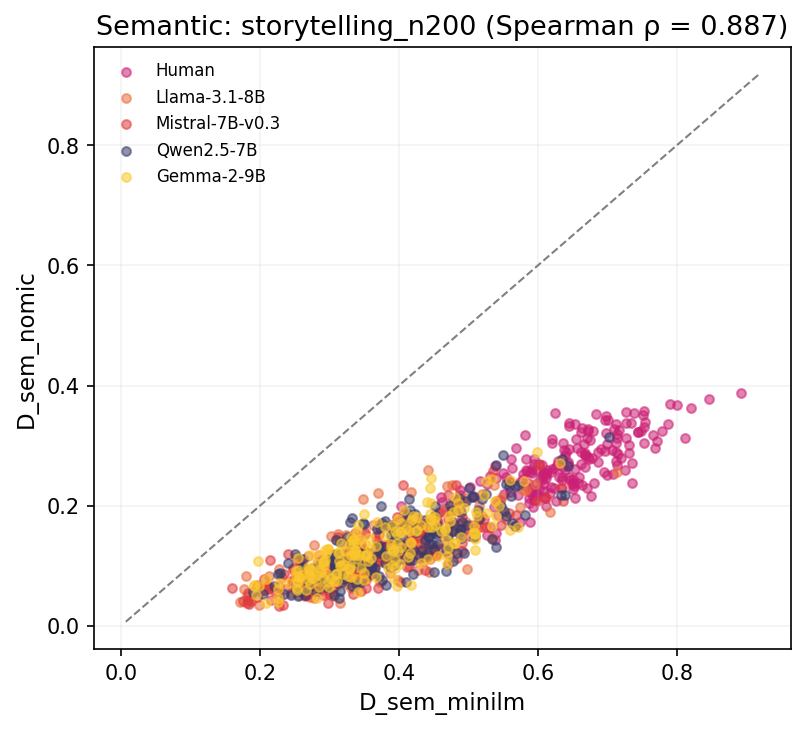

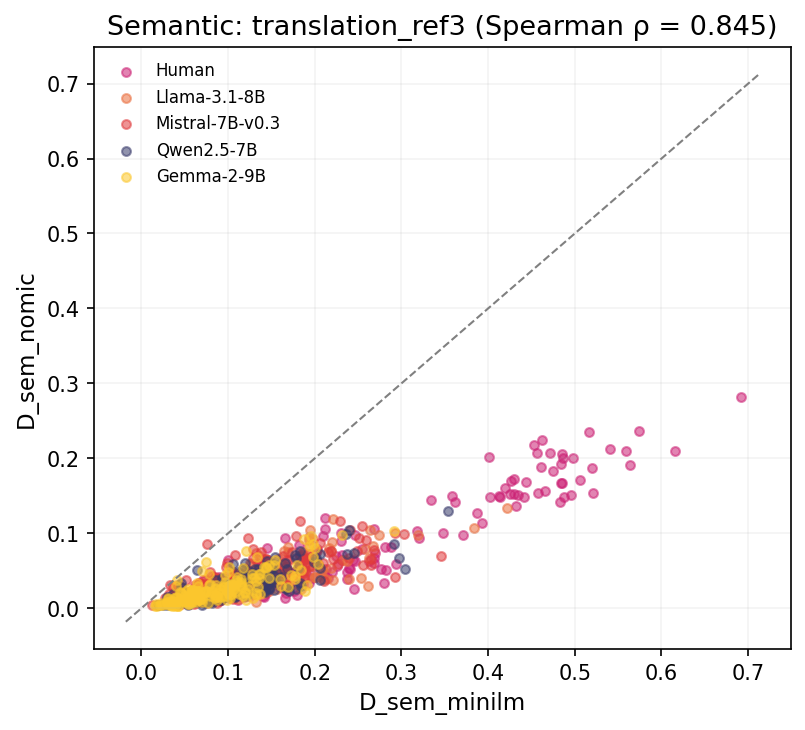

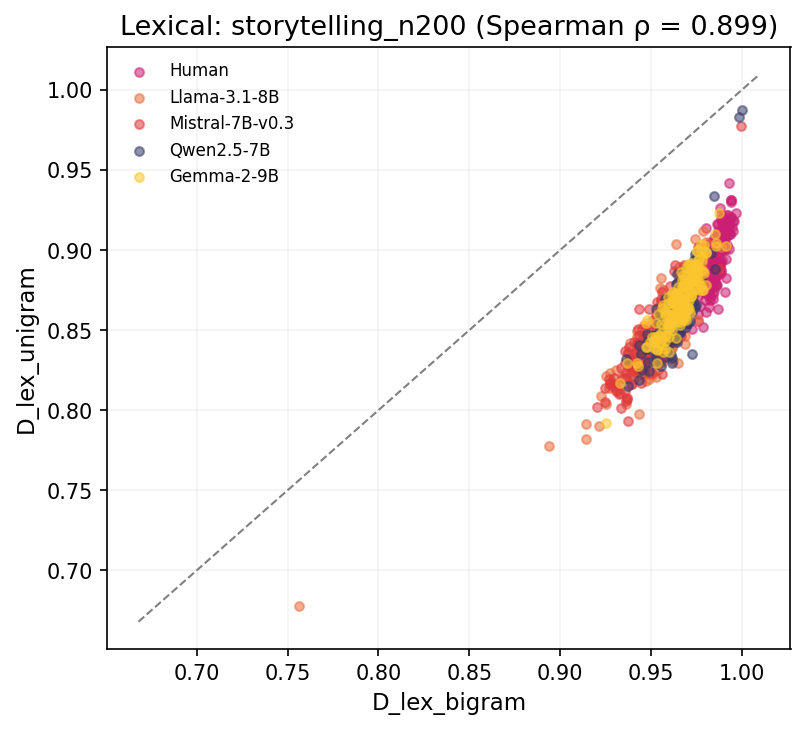

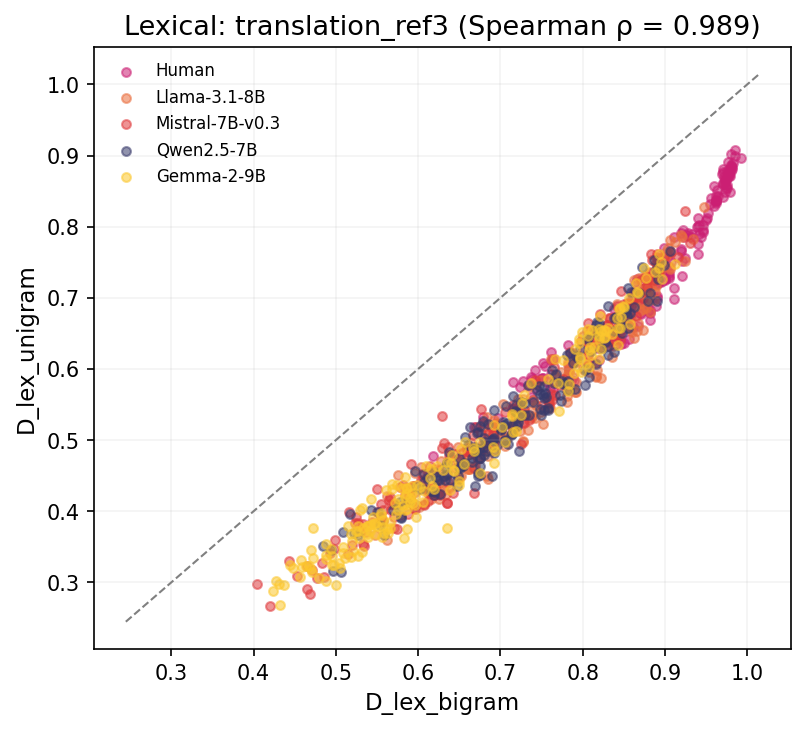

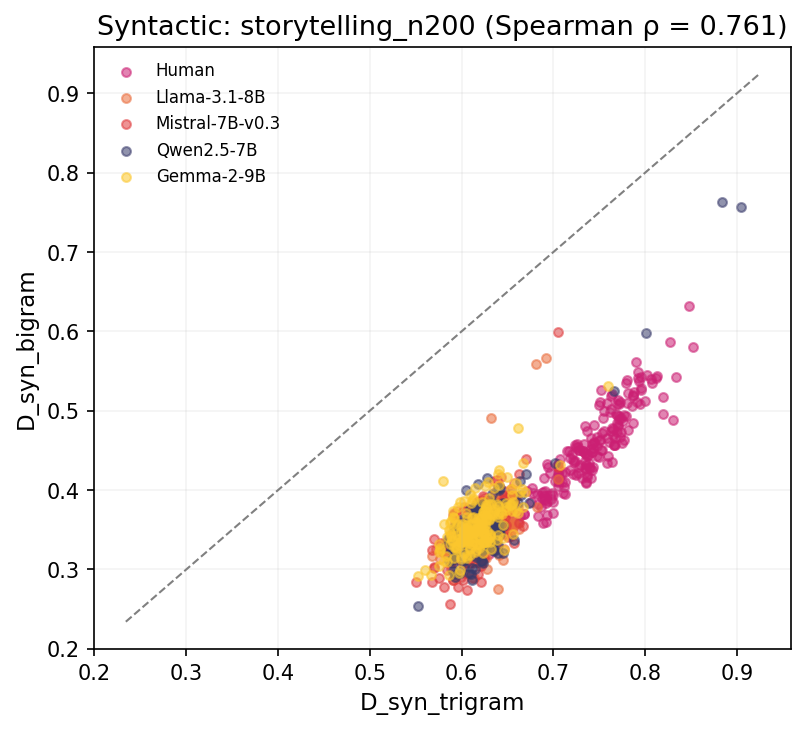

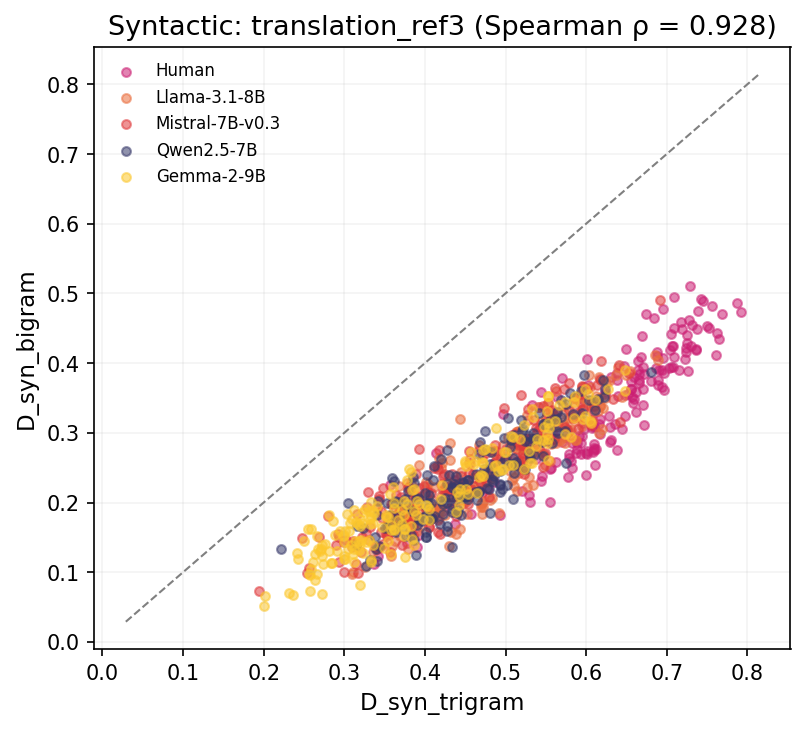

In [22]:
def plot_variant_scatter(domain, dimension, old_col, new_col):
    sub = results[results['domain'] == domain].dropna(subset=[old_col, new_col]).copy()
    rho, _ = spearmanr(sub[old_col], sub[new_col])

    fig, ax = plt.subplots(figsize=(5.5, 5))

    for source in SOURCES:
        s = sub[sub['source'] == source]
        label = MODEL_LABELS[source]
        ax.scatter(
            s[old_col],
            s[new_col],
            alpha=0.55,
            s=18,
            label=label,
            color=MODEL_COLORS[label],
        )

    # y=x is only a visual scale reference. For Semantic, the two axes are different
    # embedding spaces, so distance from the line has no calibrated interpretation.
    lo = min(sub[old_col].min(), sub[new_col].min())
    hi = max(sub[old_col].max(), sub[new_col].max())
    pad = 0.03 * (hi - lo if hi > lo else 1.0)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            linestyle='--', linewidth=1, color='grey')

    ax.set_xlabel(old_col)
    ax.set_ylabel(new_col)
    ax.set_title(f'{dimension}: {domain} (Spearman ρ = {rho:.3f})')
    ax.grid(True, alpha=0.15)
    ax.legend(frameon=False, fontsize=8)

    plt.tight_layout()
    path = FIG_DIR / f'{domain}_{dimension.lower()}_variant_scatter.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()


for dimension, (old_col, new_col) in COMPARISONS.items():
    for domain in DOMAINS:
        plot_variant_scatter(domain, dimension, old_col, new_col)

## Source Means

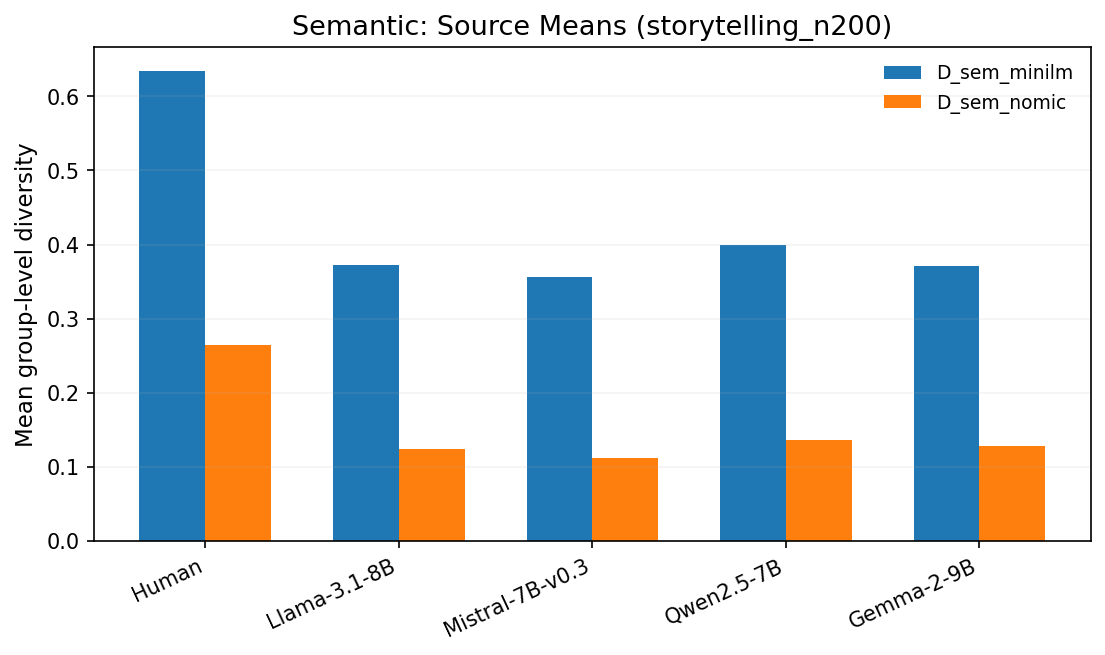

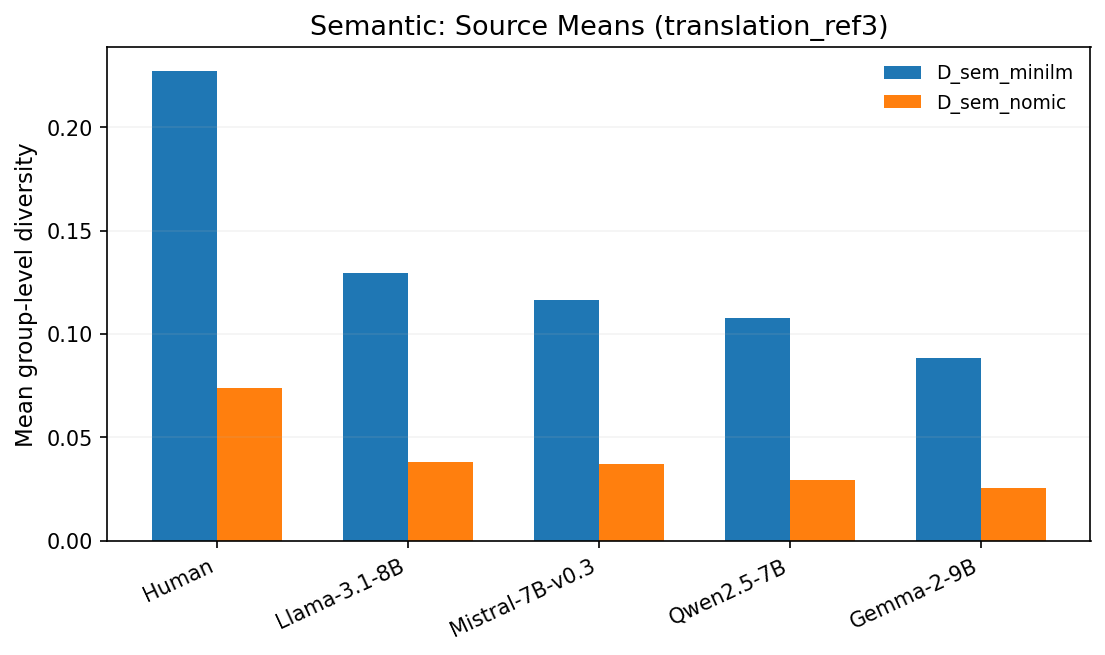

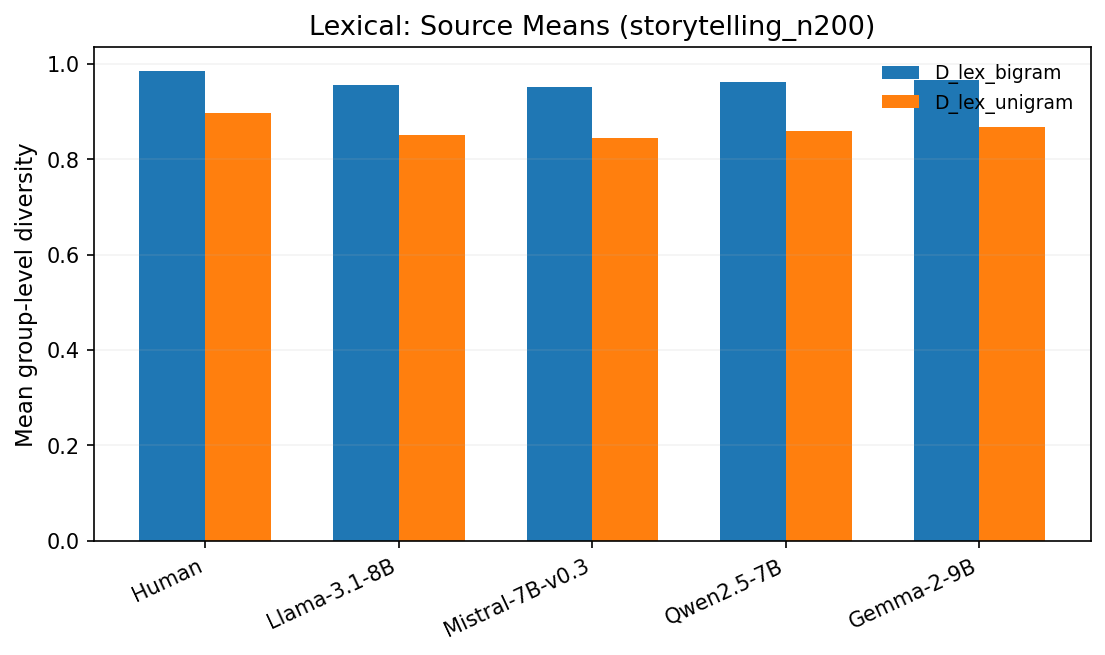

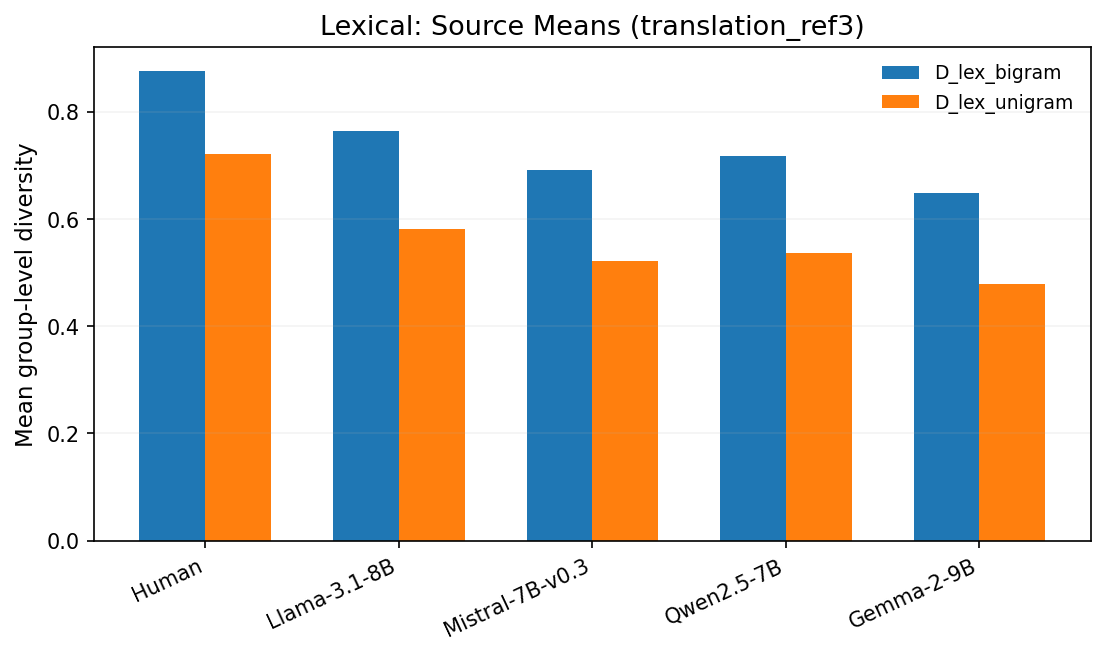

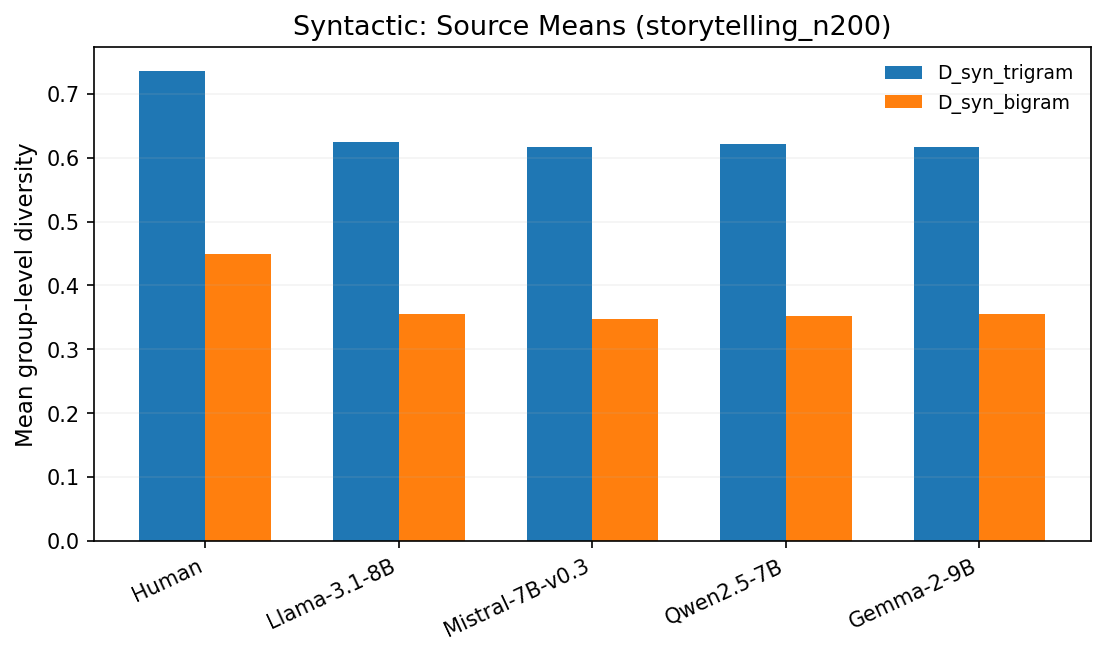

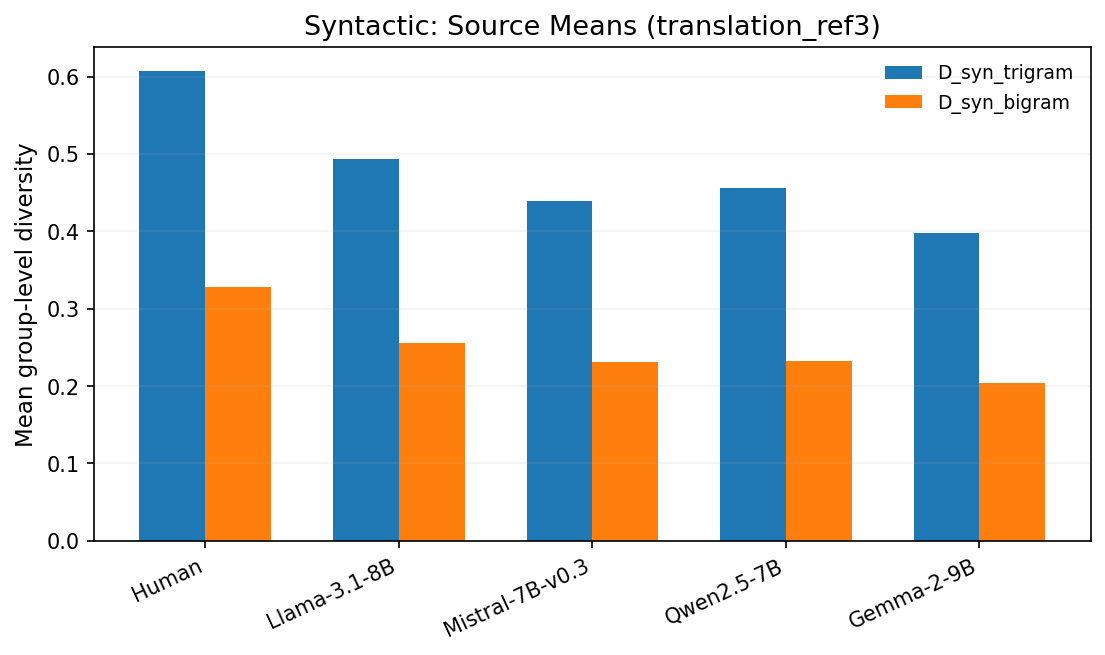

In [23]:
def plot_source_means(domain, dimension, old_col, new_col):
    s = source_means[source_means['domain'] == domain].set_index('source').loc[SOURCES]

    x = np.arange(len(SOURCES))
    width = 0.34

    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    ax.bar(x - width/2, s[old_col].values, width, label=old_col)
    ax.bar(x + width/2, s[new_col].values, width, label=new_col)

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[src] for src in SOURCES], rotation=25, ha='right')
    ax.set_ylabel('Mean group-level diversity')
    ax.set_title(f'{dimension}: Source Means ({domain})')
    ax.grid(True, alpha=0.15, axis='y')
    ax.legend(frameon=False)

    plt.tight_layout()
    path = FIG_DIR / f'{domain}_{dimension.lower()}_source_means.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()


for dimension, (old_col, new_col) in COMPARISONS.items():
    for domain in DOMAINS:
        plot_source_means(domain, dimension, old_col, new_col)

## Task-Direction Check

Compare the **mean group-level diversity** in storytelling vs. translation

In [24]:
if {'storytelling_n200', 'translation_ref3'}.issubset(set(DOMAINS)) or    {'storytelling_n200', 'translation_ref4'}.issubset(set(DOMAINS)):

    translation_domain = (
        'translation_ref3' if 'translation_ref3' in DOMAINS else 'translation_ref4'
    )

    task_means = (
        results.groupby(['domain', 'source'])[metric_cols]
        .mean()
        .reset_index()
    )

    task_rows = []

    for source in SOURCES:
        story = task_means[
            (task_means['domain'] == 'storytelling_n200')
            & (task_means['source'] == source)
        ].iloc[0]

        trans = task_means[
            (task_means['domain'] == translation_domain)
            & (task_means['source'] == source)
        ].iloc[0]

        for col in metric_cols:
            delta = trans[col] - story[col]
            task_rows.append({
                'source': source,
                'metric': col,
                'storytelling_mean': story[col],
                'translation_mean': trans[col],
                'translation_minus_storytelling': delta,
                'same_expected_contraction_direction': delta < 0,
            })

    task_direction = pd.DataFrame(task_rows)
    task_direction.to_csv(TABLE_DIR / 'task_direction_check.csv', index=False)
    display(task_direction.round(4))

else:
    print('Task-direction check skipped because both storytelling and translation were not loaded.')

,source,metric,storytelling_mean,translation_mean,translation_minus_storytelling,same_expected_contraction_direction
0,human,D_sem_minilm,0.6350,0.2274,-0.4076,True
1,human,D_sem_nomic,0.2645,0.0739,-0.1906,True
2,human,D_lex_bigram,0.9861,0.8770,-0.1092,True
3,human,D_lex_unigram,0.8966,0.7221,-0.1744,True
4,human,D_syn_trigram,0.7367,0.6078,-0.1289,True
5,human,D_syn_bigram,0.4498,0.3284,-0.1214,True
6,llama,D_sem_minilm,0.3723,0.1297,-0.2426,True
7,llama,D_sem_nomic,0.1241,0.0383,-0.0858,True
8,llama,D_lex_bigram,0.9560,0.7638,-0.1921,True
9,llama,D_lex_unigram,0.8509,0.5809,-0.2701,True


In [25]:
# Record the run configuration and resolved model revisions for reproducibility
def resolved_revision(st_model):
    try:
        return getattr(st_model[0].auto_model.config, '_commit_hash', None)
    except Exception:
        try:
            return getattr(st_model[0].auto_model, '_commit_hash', None)
        except Exception:
            return None


manifest = {
    'domains': DOMAINS,
    'n_prompts': N_PROMPTS,
    'sources': SOURCES,
    'data_fingerprint': DATA_FINGERPRINT,
    'minilm_model': MINILM_MODEL,
    'minilm_requested_revision': MINILM_REVISION,
    'minilm_resolved_revision': resolved_revision(minilm),
    'minilm_max_seq_length': int(minilm.max_seq_length),
    'nomic_model': NOMIC_MODEL,
    'nomic_prefix': NOMIC_PREFIX,
    'nomic_requested_revision': NOMIC_REVISION,
    'nomic_resolved_revision': resolved_revision(nomic),
    'nomic_max_seq_length': int(nomic.max_seq_length),
    'minilm_device': DEVICE,
    'nomic_device': NOMIC_DEVICE,
    'minilm_batch_size': MINILM_BATCH_SIZE,
    'nomic_batch_size': NOMIC_BATCH_SIZE,
    'spacy_model': 'en_core_web_sm',
    'spacy_version': spacy.__version__,
}

with open(TABLE_DIR / 'run_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print(json.dumps(manifest, indent=2))

{
  "domains": [
    "storytelling_n200",
    "translation_ref3"
  ],
  "n_prompts": 200,
  "sources": [
    "human",
    "llama",
    "mistral",
    "qwen",
    "gemma"
  ],
  "data_fingerprint": "604589b7079e3999",
  "minilm_model": "all-MiniLM-L6-v2",
  "minilm_requested_revision": null,
  "minilm_resolved_revision": "1110a243fdf4706b3f48f1d95db1a4f5529b4d41",
  "minilm_max_seq_length": 256,
  "nomic_model": "nomic-ai/nomic-embed-text-v1.5",
  "nomic_prefix": "clustering: ",
  "nomic_requested_revision": null,
  "nomic_resolved_revision": "e9b6763023c676ca8431644204f50c2b100d9aab",
  "nomic_max_seq_length": 2048,
  "minilm_device": "mps",
  "nomic_device": "cpu",
  "minilm_batch_size": 64,
  "nomic_batch_size": 4,
  "spacy_model": "en_core_web_sm",
  "spacy_version": "3.8.13"
}
